# "요즘 어떤 지역 맛집이 뜨고 있나?" 를 유튜브 데이터를 활용해 분석하는 방법

✅ 전체 분석 흐름
검색 키워드 입력

*   YouTube Data API로 인기 영상 검색
*   각 영상의 조회수, 좋아요 수, 제목, 해시태그 수집
*   데이터프레임으로 정리
*   제목 + 해시태그에서 단어 추출 → 워드클라우드 시각화


### 📦 코랩 한글폰트 설정

In [1]:
!pip install konlpy wordcloud
# 코랩 한글 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 24.7 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 34 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,684 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to 

In [ ]:
#세션다시시작

In [1]:
# 나눔 폰트 설정
import matplotlib.pyplot as plt
# 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
plt.rc('font', family='NanumGothic')

## 🔍 분석 목표:
최근 유튜브에서 많이 언급되는 지역 + 맛집 키워드 조합을 통해 뜨는 지역을 파악

##📌 분석 절차


###✅ 1. 지역 키워드 리스트 준비
먼저 분석에 활용할 지역명을 리스트로 정리.<br> 예시로 서울의 주요 지역을 사용

In [2]:
#regions = ['홍대', '강남', '이태원', '연남동', '성수동', '종로', '을지로']

###✅ 2. 각 지역 + "맛집" 조합으로 인기 영상 수집 (YouTube Data API 사용)

In [5]:
# isodate는 ISO 8601 형식의 날짜 및 시간(예: 'PT1M2S')을 파싱할 수 있는 파이썬 라이브러리
!pip install isodate

In [8]:
from googleapiclient.discovery import build
from datetime import datetime, timedelta
import pandas as pd
import re
import isodate  # ISO 8601 형식의 duration 파싱

# 🔑 유튜브 API 키
api_key = '유튜브 API'
youtube = build('youtube', 'v3', developerKey=api_key)

# 📆 최근 90일 기준 날짜 설정
published_after = (datetime.utcnow() - timedelta(days=90)).isoformat("T") + "Z"

# 📍 분석할 지역 목록 (서울 주요 지역 예시)
regions = ['홍대', '강남', '이태원', '연남동', '성수동', '종로', '을지로']

# 📥 결과 저장용 리스트
results = []

for region in regions:
    query = f"{region} 맛집"

    search_response = youtube.search().list(
        q=query,
        part='snippet',
        maxResults=10,
        type='video',
        publishedAfter=published_after,
        order='viewCount'
    ).execute()

    for item in search_response['items']:
        video_id = item['id']['videoId']
        title = item['snippet']['title']
        description = item['snippet'].get('description', '')
        video_url = f"https://www.youtube.com/watch?v={video_id}"

        # 📦 통계 + 상세정보 요청 (조회수, 좋아요수, 영상길이 포함)
        detail_response = youtube.videos().list(
            part='statistics,snippet,contentDetails',
            id=video_id
        ).execute()

        video = detail_response['items'][0]
        stats = video['statistics']
        snippet = video['snippet']
        details = video['contentDetails']

        views = int(stats.get('viewCount', 0))
        likes = int(stats.get('likeCount', 0))

        # ⏱️ 영상 길이 파싱 (ISO 8601 형식 → 초 단위로 변환)
        duration_str = details.get('duration', 'PT0S')
        duration_sec = isodate.parse_duration(duration_str).total_seconds()

        # 🧩 쇼츠 여부 판단: 60초 이하
        is_shorts = duration_sec <= 60

        # 해시태그 추출
        hashtags = re.findall(r"#\w+", description)
        hashtags_str = ', '.join(hashtags)

        # 저장
        results.append({
            '지역': region,
            '영상제목': title,
            '조회수': views,
            '좋아요수': likes,
            '해시태그': hashtags_str,
            '링크': video_url,
            '영상길이(초)': duration_sec,
            '쇼츠여부': '✅ 쇼츠' if is_shorts else '❌ 일반영상'
        })

# 데이터프레임 생성
df1 = pd.DataFrame(results)
df1

,지역,영상제목,조회수,좋아요수,해시태그,링크,영상길이(초),쇼츠여부
0,홍대,가성비 지리는 특상우설 맛집 ㄷㄷ @일하는용형 #shorts,1004674,14878,"#재슐랭, #일하는용형, #재슐랭가이드, #연남동, #연남동데이트, #연남동맛집, ...",https://www.youtube.com/watch?v=kvbkbPg_xhg,49.0,✅ 쇼츠
1,홍대,연남동가면 꼭 먹고 오는 일본식 당고,722881,7968,,https://www.youtube.com/watch?v=Ik1L2arAkdg,12.0,✅ 쇼츠
2,홍대,홍대생이 말아주는 홍대 하루종일 데이트코스,496622,4606,#광고,https://www.youtube.com/watch?v=3BtYFVh6MEY,31.0,✅ 쇼츠
3,홍대,홍대 김치볶음밥 배달맛집 김원식의 또배집,140976,2458,,https://www.youtube.com/watch?v=9k-GvqSIbHk,561.0,❌ 일반영상
4,홍대,요즘시대 12900원 뷔페?#홍대맛집#상수맛집#상수역#가성비맛집,59633,795,,https://www.youtube.com/watch?v=MrUXxPj4Dy0,15.0,✅ 쇼츠
...,...,...,...,...,...,...,...,...
65,을지로,오므라이스로 웨이팅한다는 여기,122457,2361,,https://www.youtube.com/watch?v=DdpIUHFpOUA,24.0,✅ 쇼츠
66,을지로,모두를 경악에 빠뜨린 해산물 전문 유튜버의 숨겨둔 맛집 ㄷㄷ #shorts @Raw...,223956,2428,"#보틀러, #을지로, #을지로맛집, #을지로보틀러, #을지로데이트, #회사랑, #유...",https://www.youtube.com/watch?v=2yc7lgZoE2Q,51.0,✅ 쇼츠
67,을지로,을지로 노포맛집 50년전통,28175,134,,https://www.youtube.com/watch?v=1mvOek0Q-xI,21.0,✅ 쇼츠
68,을지로,"라면을 끓여주는 bts성지라 불리는 을지로의 다방, 을지다방",55971,185,,https://www.youtube.com/watch?v=DYVGy1Er-Wc,15.0,✅ 쇼츠


💡 주요 파라미터 설명

| 파라미터                | 설명                          |
| ------------------- | --------------------------- |
| `q=query`           | 유튜브에서 검색할 키워드 (`ex: 강남 맛집`) |
| `part='snippet'`    | 제목, 설명, 채널 정보 등 기본 영상 정보 포함 |
| `type='video'`      | 영상만 검색 (쇼츠 포함)              |
| `order='viewCount'` | 조회수 기준 정렬                   |
| `publishedAfter`    | 최근 3개월 내 영상만 수집             |
| `maxResults=10`     | 지역별 최대 10개의 영상 수집           |


📌 part 파라미터

| 필드 이름           | 설명            |
| --------------- | ------------- |
| `viewCount`     | 조회수           |
| `likeCount`     | 좋아요 수         |
| `commentCount`  | 댓글 수          |
| `favoriteCount` | 즐겨찾기 수 (항상 0) |
| 'statistics' | 영상의 통계 정보(조회수, 좋아요 수 등) |

📌 주요 포인트 설명

| 필드                         | 설명                                            |
| -------------------------- | --------------------------------------------- |
| `duration`                 | 영상 길이 (ISO 8601 형식, 예: `'PT45S'`, `'PT1M2S'`) |
| `isodate.parse_duration()` | 문자열을 초 단위로 변환                                 |
| `쇼츠여부`                     | 60초 이하이면 `True`, 아니면 `False`                  |


🧠 분석 활용 예시

- 쇼츠여부 == True 인 영상만 필터링해서 인기 쇼츠만 따로 분석 가능

- 쇼츠와 일반 영상의 조회수/좋아요수/좋아요율 비교

- 쇼츠 전용 워드클라우드 또는 콘텐츠 아이디어 분석

###✅3. 데이터 정리 및 인기 지역 분석

In [9]:
# 쇼츠영상 포함한 데이터
# 📊 지역별 평균 조회수 & 좋아요 수 계산
region_summary = df1.groupby('지역')[['조회수', '좋아요수']].mean().round(1)

# 📈 인기 지역 기준으로 정렬 (조회수 기준 내림차순)
region_summary_sorted = region_summary.sort_values(by='조회수', ascending=False)

# 결과 출력
print("🔥 지역별 평균")
region_summary_sorted

🔥 지역별 평균


,조회수,좋아요수
지역,,
성수동,2269521.1,22448.0
종로,1554452.7,8927.2
강남,637258.3,4614.5
연남동,370892.9,6025.3
홍대,275149.8,3244.4
을지로,266758.1,2330.2
이태원,59259.9,1068.7


🔍 분석 포인트:<br>
평균 조회수가 높은 지역 → 사람들이 관심 많은 지역<br>
평균 좋아요수 / 조회수 비율이 높은 지역 → 콘텐츠 반응도 좋은 지역

###✅ 4. 좋아요율(좋아요수 ÷ 조회수) 기준 인기 지역 분석

In [10]:
# ⚙️ 좋아요율(좋아요수 ÷ 조회수) 컬럼 추가
df1['좋아요율'] = df1['좋아요수'] / df1['조회수']
df1['좋아요율'] = df1['좋아요율'].round(4)  # 소수점 4자리까지

# 📊 지역별 평균 좋아요율 계산
like_ratio_by_region = df1.groupby('지역')['좋아요율'].mean().sort_values(ascending=False)

# 결과 출력
like_ratio_by_region

,좋아요율
지역,
이태원,0.01687
을지로,0.01496
연남동,0.01325
홍대,0.01114
성수동,0.00959
강남,0.00719
종로,0.00680


💬 분석 포인트:<br>
이 비율이 높다는 건 같은 조회수 대비 더 많은 좋아요를 받은 영상이라는 뜻

사람들이 적극적으로 반응한 콘텐츠가 많은 지역이라 판단할 수 있음

###✅ 5. 쇼츠만 필터링한 인기 지역 분석
쇼츠는 일반적으로 60초 이하의 세로형 짧은 영상

In [11]:
# 영상 길이 60초 이하 → 쇼츠로 필터링
shorts_df = df1[df1['영상길이(초)'] <= 60]
shorts_df.head()

,지역,영상제목,조회수,좋아요수,해시태그,링크,영상길이(초),쇼츠여부,좋아요율
0,홍대,가성비 지리는 특상우설 맛집 ㄷㄷ @일하는용형 #shorts,1004674,14878,"#재슐랭, #일하는용형, #재슐랭가이드, #연남동, #연남동데이트, #연남동맛집, ...",https://www.youtube.com/watch?v=kvbkbPg_xhg,49.0,✅ 쇼츠,0.0148
1,홍대,연남동가면 꼭 먹고 오는 일본식 당고,722881,7968,,https://www.youtube.com/watch?v=Ik1L2arAkdg,12.0,✅ 쇼츠,0.0110
2,홍대,홍대생이 말아주는 홍대 하루종일 데이트코스,496622,4606,#광고,https://www.youtube.com/watch?v=3BtYFVh6MEY,31.0,✅ 쇼츠,0.0093
4,홍대,요즘시대 12900원 뷔페?#홍대맛집#상수맛집#상수역#가성비맛집,59633,795,,https://www.youtube.com/watch?v=MrUXxPj4Dy0,15.0,✅ 쇼츠,0.0133
5,홍대,여기가 서울 만나 싶었던 벚꽃 아래 딸기 가득한 너무 좋은 요즘 맛집,141934,191,,https://www.youtube.com/watch?v=zi1Z5OyiDng,10.0,✅ 쇼츠,0.0013


In [12]:
# 📊 쇼츠 영상만 추출하여 지역별 평균 조회수 & 좋아요수 계산
shorts_summary = shorts_df.groupby('지역')[['조회수', '좋아요수']].mean().round(1)

# 조회수 기준 정렬
shorts_summary_sorted = shorts_summary.sort_values(by='조회수', ascending=False)

# 결과 출력
shorts_summary_sorted

,조회수,좋아요수
지역,,
성수동,2984239.0,28966.4
종로,1554452.7,8927.2
강남,640093.6,4237.0
연남동,408926.0,6620.6
을지로,307374.8,2388.0
홍대,290058.0,3331.8
이태원,60273.1,1112.9


In [13]:
# ⚙️ 쇼츠 좋아요율(좋아요수 ÷ 조회수) 컬럼 추가
df1['좋아요율'] = df1['좋아요수'] / df1['조회수']
df1['좋아요율'] = df1['좋아요율'].round(4)  # 소수점 4자리까지

# 📊 지역별 평균 좋아요율 계산
like_ratio_by_region = df1.groupby('지역')['좋아요율'].mean().sort_values(ascending=False)

# 결과 출력
like_ratio_by_region

,좋아요율
지역,
이태원,0.01687
을지로,0.01496
연남동,0.01325
홍대,0.01114
성수동,0.00959
강남,0.00719
종로,0.00680


##📝 정리

| 분석 항목           | 의미                       |
| --------------- | ------------------------ |
| **좋아요율 높은 지역**  | 유저 반응이 좋은 콘텐츠가 집중된 지역    |
| **쇼츠 인기 지역**    | 짧은 영상으로 관심을 끌고 있는 지역     |
| **쇼츠 비중 높은 지역** | 짧은 콘텐츠 전략을 집중하는 지역일 수 있음 |




---



##🚀 워드클라우드로 영상 제목에서 자주 등장하는 음식 종류나 장소는?

In [14]:
#워드클라우드
!pip install wordcloud konlpy matplotlib

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.font_manager as fm

###✅ 제목 + 해시태그 기반 워드클라우드 생성 코드

In [16]:
df1.head()

,지역,영상제목,조회수,좋아요수,해시태그,링크,영상길이(초),쇼츠여부,좋아요율
0,홍대,가성비 지리는 특상우설 맛집 ㄷㄷ @일하는용형 #shorts,1004674,14878,"#재슐랭, #일하는용형, #재슐랭가이드, #연남동, #연남동데이트, #연남동맛집, ...",https://www.youtube.com/watch?v=kvbkbPg_xhg,49.0,✅ 쇼츠,0.0148
1,홍대,연남동가면 꼭 먹고 오는 일본식 당고,722881,7968,,https://www.youtube.com/watch?v=Ik1L2arAkdg,12.0,✅ 쇼츠,0.0110
2,홍대,홍대생이 말아주는 홍대 하루종일 데이트코스,496622,4606,#광고,https://www.youtube.com/watch?v=3BtYFVh6MEY,31.0,✅ 쇼츠,0.0093
3,홍대,홍대 김치볶음밥 배달맛집 김원식의 또배집,140976,2458,,https://www.youtube.com/watch?v=9k-GvqSIbHk,561.0,❌ 일반영상,0.0174
4,홍대,요즘시대 12900원 뷔페?#홍대맛집#상수맛집#상수역#가성비맛집,59633,795,,https://www.youtube.com/watch?v=MrUXxPj4Dy0,15.0,✅ 쇼츠,0.0133


In [17]:
# 결측치 제거
df1['해시태그'] = df1['해시태그'].fillna('')

# 제목과 해시태그를 합쳐서 텍스트 생성
df1['combined_text'] = df1['영상제목'] + ' ' + df1['해시태그']

# 모든 텍스트를 하나로 합치기
text_data = ' '.join(df1['combined_text'])

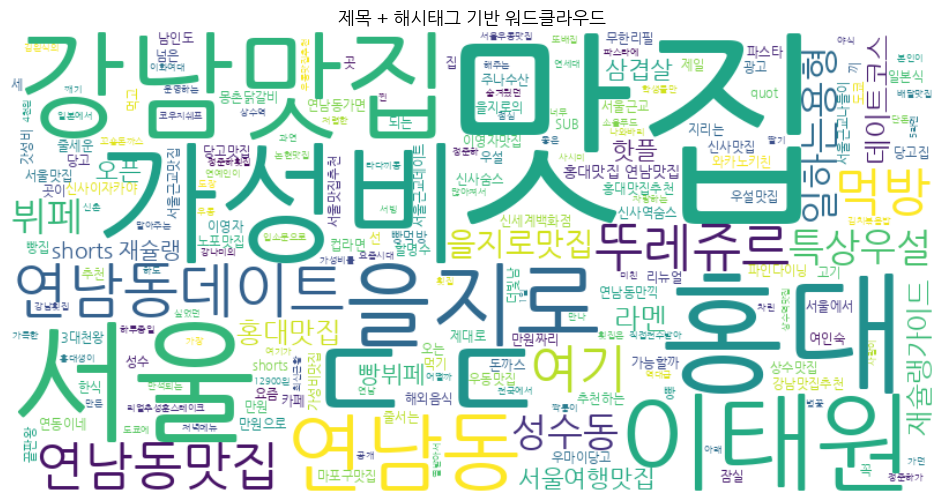

In [18]:
# 워드클라우드 객체 생성
wordcloud = WordCloud(
    font_path=font_path,       # 한글 폰트 경로
    width=800,
    height=400,
    background_color='white',
    max_words=200
).generate(text_data)

# 시각화
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("제목 + 해시태그 기반 워드클라우드", fontsize=13)
plt.show()



---

